## Variable Relationships: Correlation Analysis

To examine the relationship between team ranking advantage and match performance, we analyze the correlation between `rank_difference` and `home_goal_diff`.

We define:

`rank_difference = away_rank - home_rank`

Because lower FIFA rank numbers are better, a positive `rank_difference` means the home team was ranked better than the away team.

We also define:

`home_goal_diff = home_score - away_score`

A positive `home_goal_diff` means the home team scored more goals than the away team.

## Load Data

In [1]:
import pandas as pd
from scipy.stats import pearsonr

# Load final feature-engineered dataset
df = pd.read_csv("../data/processed/match_data.csv")

df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,home_recent_win_rate,away_recent_win_rate,home_recent_goal_diff,away_recent_goal_diff,home_rank,away_rank,rank_difference,result
0,1993-01-20,Zambia,Namibia,4,0,FIFA World Cup qualification,False,1.0,0.0,2.0,-1.0,32.0,158.0,126.0,home_win
1,1993-01-31,Tunisia,Ethiopia,3,0,FIFA World Cup qualification,False,1.0,0.0,5.0,-1.0,38.0,85.0,47.0,home_win
2,1993-01-31,Zimbabwe,Angola,2,1,FIFA World Cup qualification,False,0.5,0.0,0.5,0.0,54.0,102.0,48.0,home_win
3,1993-01-31,Morocco,Benin,5,0,FIFA World Cup qualification,False,1.0,0.0,1.0,-5.0,41.0,127.0,86.0,home_win
4,1993-01-31,Egypt,Togo,3,0,FIFA World Cup qualification,False,0.0,0.0,0.0,-1.0,21.0,101.0,80.0,home_win


## Create Goal Difference Variable

In [2]:
# Create goal difference from the home team's perspective
df["home_goal_diff"] = df["home_score"] - df["away_score"]

# Preview relevant columns
df[
    [
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "home_rank",
        "away_rank",
        "rank_difference",
        "home_goal_diff"
    ]
].head()

,home_team,away_team,home_score,away_score,home_rank,away_rank,rank_difference,home_goal_diff
0,Zambia,Namibia,4,0,32.0,158.0,126.0,4
1,Tunisia,Ethiopia,3,0,38.0,85.0,47.0,3
2,Zimbabwe,Angola,2,1,54.0,102.0,48.0,1
3,Morocco,Benin,5,0,41.0,127.0,86.0,5
4,Egypt,Togo,3,0,21.0,101.0,80.0,3


## Calculate Correlation

In [3]:
# Calculate Pearson correlation between ranking advantage and goal difference
corr, p_value = pearsonr(df["rank_difference"], df["home_goal_diff"])

print("Correlation Analysis")
print("Variables: rank_difference and home_goal_diff")
print("\nPearson correlation:", round(corr, 4))

if p_value < 0.001:
    print("P-value: < 0.001")
else:
    print("P-value:", round(p_value, 4))

Correlation Analysis
Variables: rank_difference and home_goal_diff

Pearson correlation: 0.5914
P-value: < 0.001


## Interpret Strength of Correlation

In [4]:
abs_corr = abs(corr)

if abs_corr < 0.1:
    strength = "very weak"
elif abs_corr < 0.3:
    strength = "weak"
elif abs_corr < 0.5:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if corr > 0 else "negative"

print(f"The correlation is {direction} and {strength}.")

The correlation is positive and strong.


## Correlation Visualization

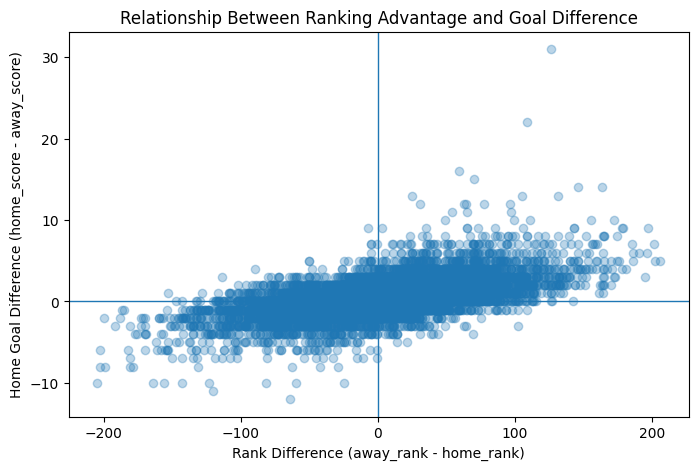

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["rank_difference"], df["home_goal_diff"], alpha=0.3)

plt.xlabel("Rank Difference (away_rank - home_rank)")
plt.ylabel("Home Goal Difference (home_score - away_score)")
plt.title("Relationship Between Ranking Advantage and Goal Difference")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.show()

## Correlation Result

We calculated the Pearson correlation between `rank_difference` and `home_goal_diff`.

The Pearson correlation was **0.5914**, with a p-value of **< 0.001**. This indicates a strong positive relationship between ranking advantage and goal difference.

Since `rank_difference = away_rank - home_rank`, higher positive values mean the home team had a stronger ranking advantage. Since `home_goal_diff = home_score - away_score`, higher positive values mean the home team scored more goals than the away team.

Therefore, this result suggests that as the home team's ranking advantage increases, the home team's goal difference also tends to increase. In other words, when the home team is ranked much better than the away team, the home team is more likely to win by a larger margin.

## Causal Interpretation

The correlation between `rank_difference` and `home_goal_diff` should **not** be interpreted causally.

Although we found a strong positive correlation between ranking advantage and goal difference, this does not mean that FIFA ranking directly causes a team to score more goals or win by a larger margin. FIFA rankings are not randomly assigned. They are based on previous team performance, so they already reflect many qualities that make a team stronger.

There are also many possible confounding variables that could influence both FIFA ranking and match outcome. These include overall team quality, recent form, player injuries, roster strength, coaching, opponent strength, travel, home-field advantage, tournament importance, and whether the match was played at a neutral site.

For example, a highly ranked team may win by more goals not because the ranking itself caused the win, but because that team has better players, stronger tactics, more experience, or better recent performance. These same factors may also be what caused the team to have a high FIFA ranking in the first place.

Because our data is observational and not experimental, we cannot isolate the independent effect of FIFA ranking on goal difference. Therefore, this correlation is useful for identifying patterns and building a predictive model, but it does not prove that ranking advantage causes better match performance.